In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set default plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
df = pd.read_csv('../data/delhi_ncr_aqi_dataset.csv')

print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Shape: (201664, 25)
Rows: 201,664
Columns: 25


In [7]:
df.head()

,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,01-01-2020 06:00,01-01-2020,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,01-01-2020 12:00,01-01-2020,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,01-01-2020 18:00,01-01-2020,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,01-01-2020 23:00,01-01-2020,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
4,01-01-2020 06:00,01-01-2020,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe


In [8]:
print("=== Dataset Information ===")
df.info()

=== Dataset Information ===
<class 'pandas.DataFrame'>
RangeIndex: 201664 entries, 0 to 201663
Data columns (total 25 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   datetime      201664 non-null  str    
 1   date          201664 non-null  str    
 2   year          201664 non-null  int64  
 3   month         201664 non-null  int64  
 4   day           201664 non-null  int64  
 5   hour          201664 non-null  int64  
 6   day_of_week   201664 non-null  str    
 7   is_weekend    201664 non-null  int64  
 8   season        201664 non-null  str    
 9   city          201664 non-null  str    
 10  station       201664 non-null  str    
 11  latitude      201664 non-null  float64
 12  longitude     201664 non-null  float64
 13  pm25          201664 non-null  float64
 14  pm10          201664 non-null  float64
 15  no2           201664 non-null  float64
 16  so2           201664 non-null  float64
 17  co            201664 non-null  

In [9]:
print("=== Basic Statistics ===")
df.describe().round(2)

=== Basic Statistics ===


,year,month,day,hour,is_weekend,latitude,longitude,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi
count,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00
mean,2022.50,6.52,15.73,14.75,0.29,28.60,77.21,183.42,348.57,69.76,16.03,3.03,27.19,26.90,61.04,10.53,5.01,265.83
std,1.71,3.45,8.80,6.38,0.45,0.11,0.13,193.14,370.02,75.97,17.20,3.28,13.57,8.98,24.74,6.05,3.69,171.51
min,2020.00,1.00,1.00,6.00,0.00,28.37,77.03,15.00,24.00,8.00,4.00,0.30,12.00,6.00,20.00,2.10,0.20,25.00
25%,2021.00,4.00,8.00,10.50,0.00,28.53,77.07,55.30,104.10,19.90,4.50,0.87,18.00,19.90,39.00,5.90,1.90,103.00
50%,2022.50,7.00,16.00,15.00,0.00,28.62,77.20,99.50,189.80,38.30,8.70,1.69,23.30,27.60,58.00,9.20,4.40,232.00
75%,2024.00,10.00,23.00,19.25,1.00,28.67,77.32,254.70,481.20,94.00,20.90,4.12,31.80,33.50,83.00,14.20,7.10,464.00
max,2025.00,12.00,31.00,23.00,1.00,28.78,77.50,900.00,1979.70,593.50,121.60,22.67,84.00,44.80,100.00,31.50,15.00,500.00


In [10]:
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

=== Missing Values ===
datetime        0
date            0
year            0
month           0
day             0
hour            0
day_of_week     0
is_weekend      0
season          0
city            0
station         0
latitude        0
longitude       0
pm25            0
pm10            0
no2             0
so2             0
co              0
o3              0
temperature     0
humidity        0
wind_speed      0
visibility      0
aqi             0
aqi_category    0
dtype: int64

Total missing values: 0


In [11]:
print("=== Duplicate Rows ===")
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

=== Duplicate Rows ===
Total duplicate rows: 0


In [12]:
print("=== Unique Values in Categorical Columns ===")
print(f"Cities ({df['city'].nunique()}): {df['city'].unique().tolist()}")
print(f"\nSeasons ({df['season'].nunique()}): {df['season'].unique().tolist()}")
print(f"\nAQI Categories ({df['aqi_category'].nunique()}): {df['aqi_category'].unique().tolist()}")
print(f"\nStations ({df['station'].nunique()}):")
for s in sorted(df['station'].unique()):
    print(f"  - {s}")

=== Unique Values in Categorical Columns ===
Cities (5): ['Delhi', 'Noida', 'Gurugram', 'Faridabad', 'Ghaziabad']

Seasons (4): ['winter', 'summer', 'monsoon', 'post_monsoon']

AQI Categories (6): ['Severe', 'Very Poor', 'Poor', 'Moderate', 'Satisfactory', 'Good']

Stations (23):
  - Anand Vihar, Delhi
  - Bawana, Delhi
  - Dwarka Sec 8, Delhi
  - Faridabad New Town
  - Faridabad Sec 16A
  - Ghaziabad Loni
  - Ghaziabad Vasundhara
  - Greater Noida
  - Gurugram Sec 51
  - Gurugram Vikas Sadan
  - ITO, Delhi
  - Jahangirpuri, Delhi
  - Mandir Marg, Delhi
  - NSIT Dwarka, Delhi
  - Noida Sec 125
  - Noida Sec 62
  - Okhla Phase 2, Delhi
  - Punjabi Bagh, Delhi
  - RK Puram, Delhi
  - Rohini, Delhi
  - Shadipur, Delhi
  - Siri Fort, Delhi
  - Wazirpur, Delhi


In [13]:
print("=== Time Coverage ===")
print(f"Start date : {df['datetime'].min()}")
print(f"End date   : {df['datetime'].max()}")
print(f"Total years: {df['year'].nunique()} ({sorted(df['year'].unique())})")
print(f"Hours recorded: {sorted(df['hour'].unique())}")
print(f"\nRecords per city:")
print(df['city'].value_counts())
print(f"\nRecords per season:")
print(df['season'].value_counts())

=== Time Coverage ===
Start date : 01-01-2020 06:00
End date   : 31-12-2025 23:00
Total years: 6 ([np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)])
Hours recorded: [np.int64(6), np.int64(12), np.int64(18), np.int64(23)]

Records per city:
city
Delhi        122752
Noida         26304
Gurugram      17536
Faridabad     17536
Ghaziabad     17536
Name: count, dtype: int64

Records per season:
season
monsoon         67344
winter          66424
summer          50784
post_monsoon    17112
Name: count, dtype: int64


In [14]:
print("=== Column Summary ===")
summary = pd.DataFrame({
    'Data Type': df.dtypes,
    'Null Count': df.isnull().sum(),
    'Unique Values': df.nunique(),
    'Sample Value': df.iloc[0]
})
print(summary)

=== Column Summary ===
             Data Type  Null Count  Unique Values        Sample Value
datetime           str           0           8768    01-01-2020 06:00
date               str           0           2192          01-01-2020
year             int64           0              6                2020
month            int64           0             12                   1
day              int64           0             31                   1
hour             int64           0              4                   6
day_of_week        str           0              7           Wednesday
is_weekend       int64           0              2                   0
season             str           0              4              winter
city               str           0              5               Delhi
station            str           0             23  Anand Vihar, Delhi
latitude       float64           0             23             28.6469
longitude      float64           0             23             77.31

In [15]:
print("=== AQI Summary Statistics ===")
print(f"Mean AQI   : {df['aqi'].mean():.2f}")
print(f"Median AQI : {df['aqi'].median():.2f}")
print(f"Std Dev    : {df['aqi'].std():.2f}")
print(f"Min AQI    : {df['aqi'].min():.2f}")
print(f"Max AQI    : {df['aqi'].max():.2f}")
print(f"\nAQI Category Breakdown:")
print(df['aqi_category'].value_counts())
print(f"\nAQI Category Breakdown (%):")
print((df['aqi_category'].value_counts(normalize=True) * 100).round(2))

=== AQI Summary Statistics ===
Mean AQI   : 265.83
Median AQI : 232.00
Std Dev    : 171.51
Min AQI    : 25.00
Max AQI    : 500.00

AQI Category Breakdown:
aqi_category
Severe          60102
Moderate        45397
Satisfactory    32860
Very Poor       29674
Poor            18843
Good            14788
Name: count, dtype: int64

AQI Category Breakdown (%):
aqi_category
Severe          29.80
Moderate        22.51
Satisfactory    16.29
Very Poor       14.71
Poor             9.34
Good             7.33
Name: proportion, dtype: float64


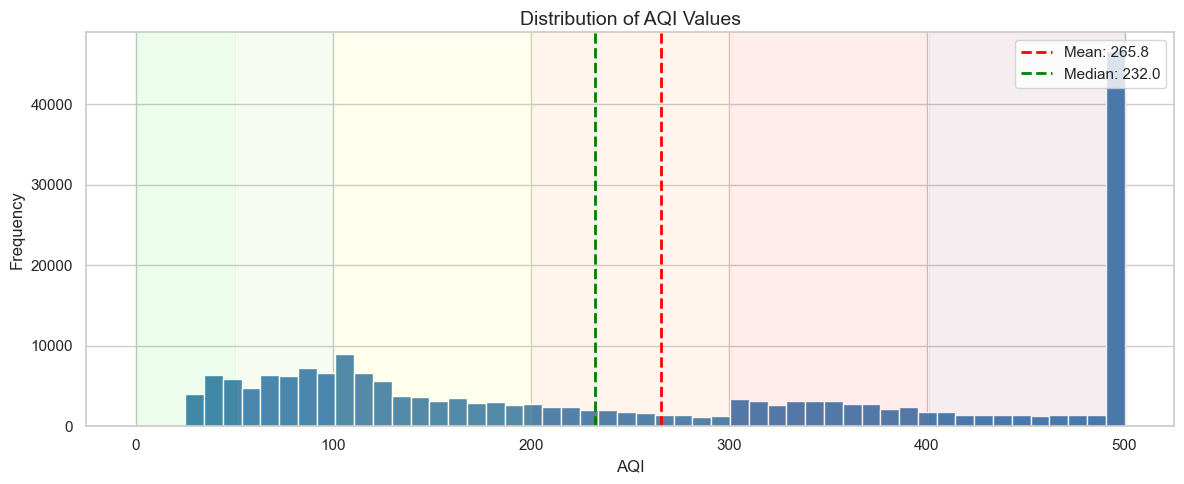

In [16]:
plt.figure(figsize=(12, 5))
plt.hist(df['aqi'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of AQI Values', fontsize=14)
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.axvline(df['aqi'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f"Mean: {df['aqi'].mean():.1f}")
plt.axvline(df['aqi'].median(), color='green', linestyle='--', 
            linewidth=2, label=f"Median: {df['aqi'].median():.1f}")

# Add AQI category bands
bands = [(0,50,'#00e400','Good'), (51,100,'#92d050','Satisfactory'),
         (101,200,'#ffff00','Moderate'), (201,300,'#ff7e00','Poor'),
         (301,400,'#ff0000','Very Poor'), (401,500,'#7e0023','Severe')]
for low, high, color, label in bands:
    plt.axvspan(low, high, alpha=0.07, color=color)

plt.legend()
plt.tight_layout()
plt.savefig('../plots/aqi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

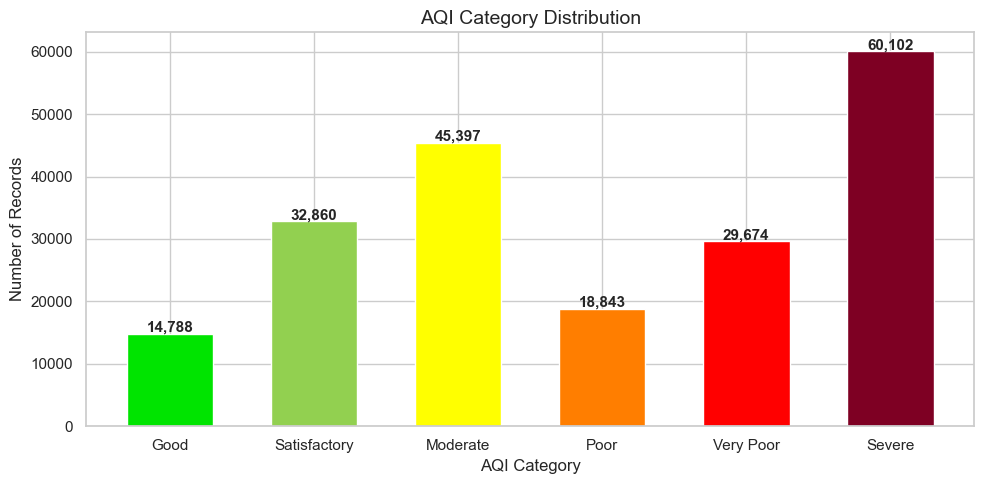

In [17]:
category_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
category_counts = df['aqi_category'].value_counts().reindex(category_order)
colors = ['#00e400', '#92d050', '#ffff00', '#ff7e00', '#ff0000', '#7e0023']

plt.figure(figsize=(10, 5))
bars = plt.bar(category_counts.index, category_counts.values, 
               color=colors, edgecolor='white', width=0.6)

# Add value labels on top of each bar
for bar, val in zip(bars, category_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'{val:,}', ha='center', fontsize=11, fontweight='bold')

plt.title('AQI Category Distribution', fontsize=14)
plt.xlabel('AQI Category')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.savefig('../plots/aqi_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

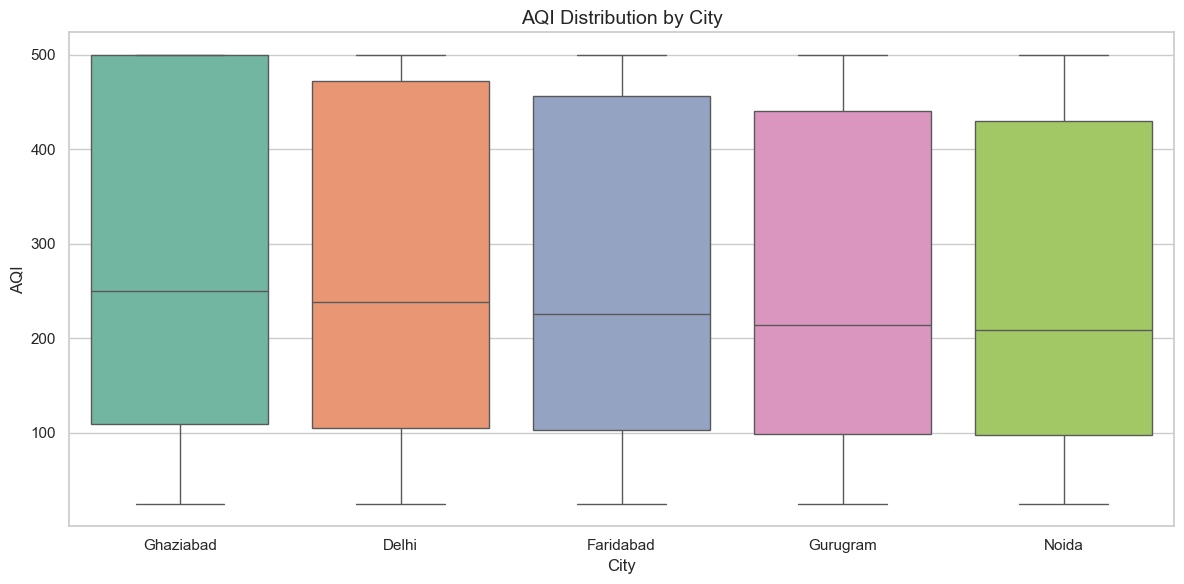

In [21]:
city_order = df.groupby('city')['aqi'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='city', y='aqi', order=city_order, palette='Set2')

plt.title('AQI Distribution by City', fontsize=14)
plt.xlabel('City')
plt.ylabel('AQI')
plt.tight_layout()
plt.savefig('../plots/city_aqi_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

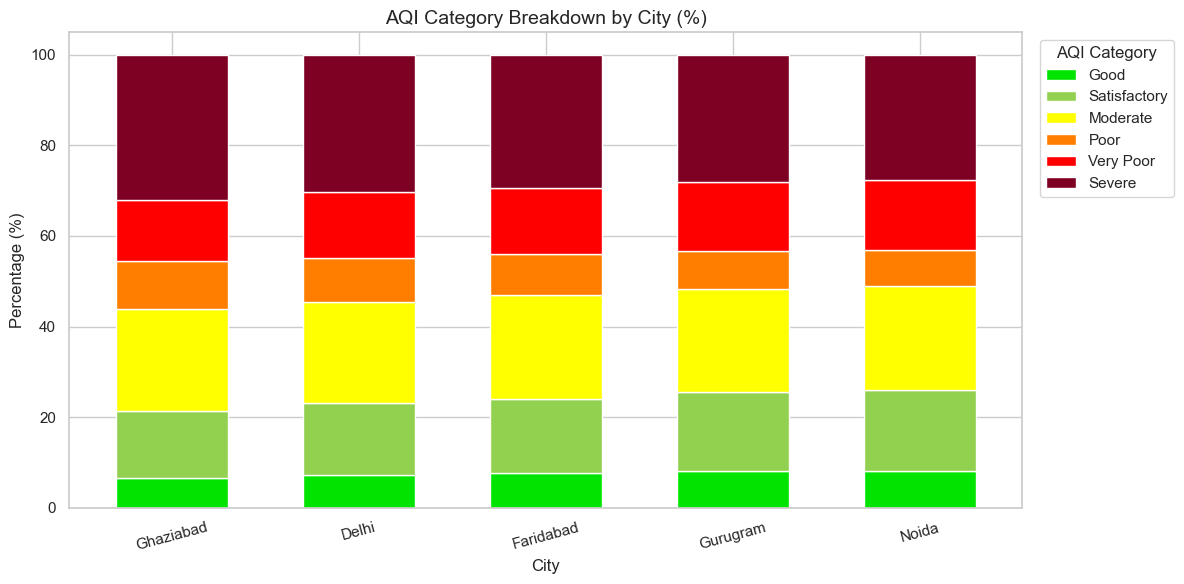

In [22]:
category_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
colors = ['#00e400', '#92d050', '#ffff00', '#ff7e00', '#ff0000', '#7e0023']

# Calculate percentage breakdown
city_cat = df.groupby(['city', 'aqi_category']).size().unstack(fill_value=0)
city_cat = city_cat[category_order]
city_cat_pct = city_cat.div(city_cat.sum(axis=1), axis=0) * 100

# Sort cities by Severe %
city_cat_pct = city_cat_pct.sort_values('Severe', ascending=False)

city_cat_pct.plot(kind='bar', stacked=True, color=colors,
                  figsize=(12, 6), edgecolor='white', width=0.6)

plt.title('AQI Category Breakdown by City (%)', fontsize=14)
plt.xlabel('City')
plt.ylabel('Percentage (%)')
plt.legend(title='AQI Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../plots/city_category_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

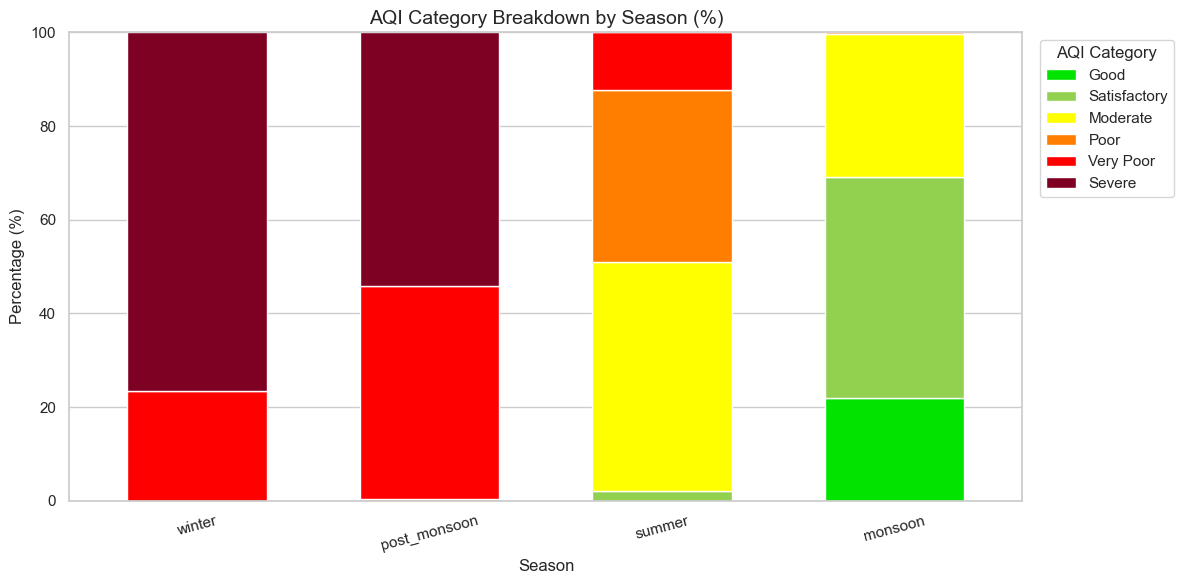

In [28]:
category_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
colors = ['#00e400', '#92d050', '#ffff00', '#ff7e00', '#ff0000', '#7e0023']

season_cat = df.groupby(['season', 'aqi_category']).size().unstack(fill_value=0)
season_cat = season_cat[category_order]
season_cat_pct = season_cat.div(season_cat.sum(axis=1), axis=0) * 100
season_cat_pct = season_cat_pct.reindex(season_order)

season_cat_pct.plot(kind='bar', stacked=True, color=colors,
                    figsize=(12, 6), edgecolor='white', width=0.6)

plt.title('AQI Category Breakdown by Season (%)', fontsize=14)
plt.xlabel('Season')
plt.ylabel('Percentage (%)')
plt.legend(title='AQI Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../plots/season_category_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

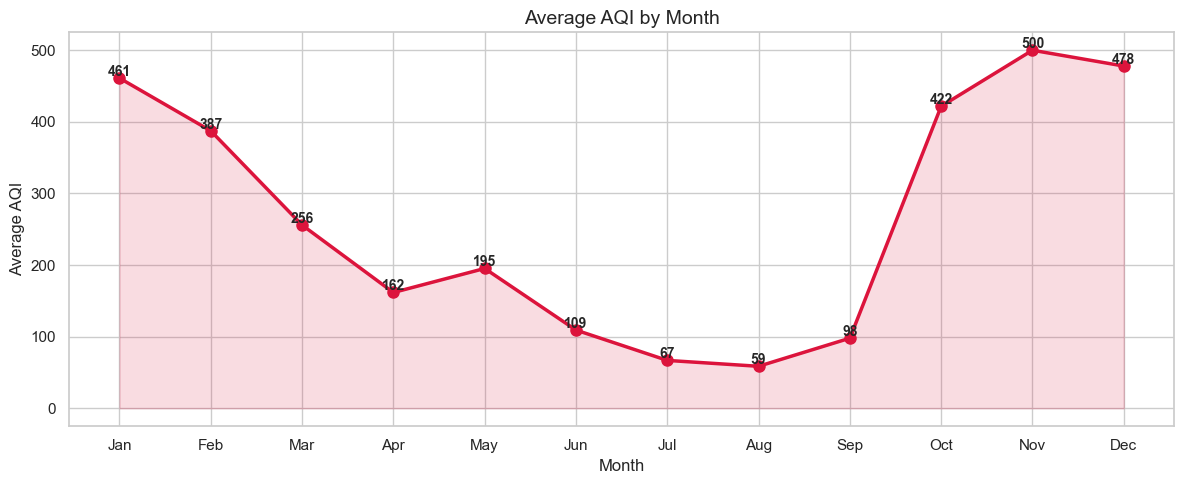

In [30]:
monthly_aqi = df.groupby('month')['aqi'].mean().round(2)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12, 5))
plt.plot(monthly_aqi.index, monthly_aqi.values, marker='o',
         color='crimson', linewidth=2.5, markersize=8)
plt.fill_between(monthly_aqi.index, monthly_aqi.values,
                 alpha=0.15, color='crimson')

for x, y in zip(monthly_aqi.index, monthly_aqi.values):
    plt.text(x, y + 3, f'{y:.0f}', ha='center',
             fontsize=10, fontweight='bold')

plt.title('Average AQI by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.xticks(range(1, 13), month_labels)
plt.tight_layout()
plt.savefig('../plots/monthly_aqi.png', dpi=150, bbox_inches='tight')
plt.show()

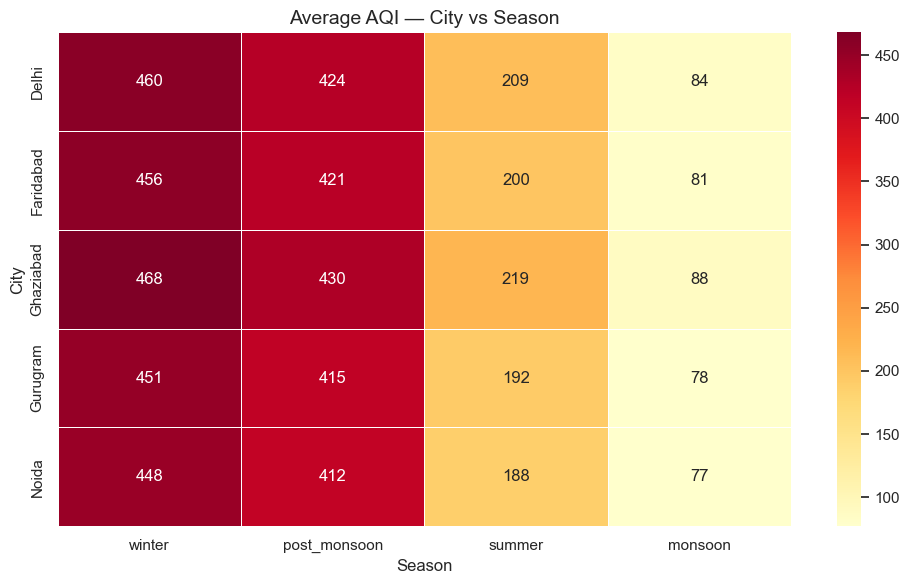

In [31]:
pivot_season_city = df.pivot_table(values='aqi',
                                    index='city',
                                    columns='season',
                                    aggfunc='mean').round(0)
pivot_season_city = pivot_season_city[season_order]

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_season_city, annot=True, fmt='.0f',
            cmap='YlOrRd', linewidths=0.5, annot_kws={'size': 12})

plt.title('Average AQI — City vs Season', fontsize=14)
plt.xlabel('Season')
plt.ylabel('City')
plt.tight_layout()
plt.savefig('../plots/city_season_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

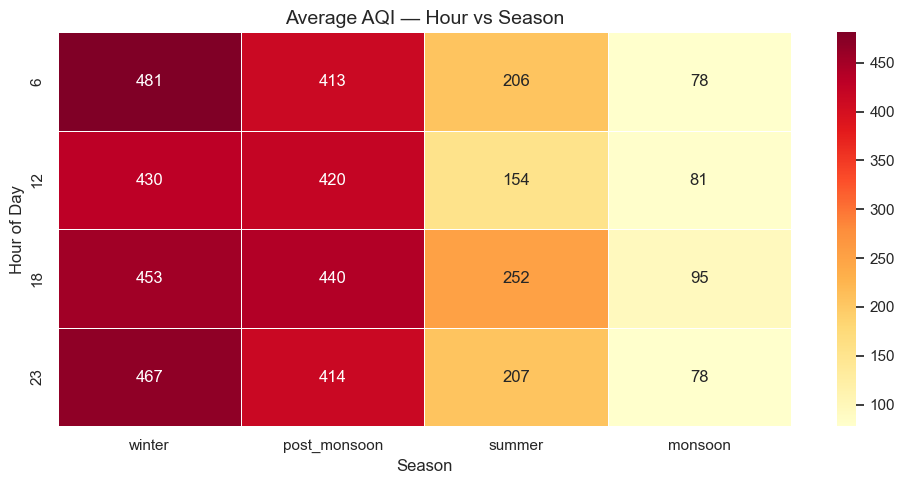

In [32]:
pivot_hour_season = df.pivot_table(values='aqi',
                                    index='hour',
                                    columns='season',
                                    aggfunc='mean').round(0)
pivot_hour_season = pivot_hour_season[season_order]

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_hour_season, annot=True, fmt='.0f',
            cmap='YlOrRd', linewidths=0.5, annot_kws={'size': 12})

plt.title('Average AQI — Hour vs Season', fontsize=14)
plt.xlabel('Season')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.savefig('../plots/hour_season_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

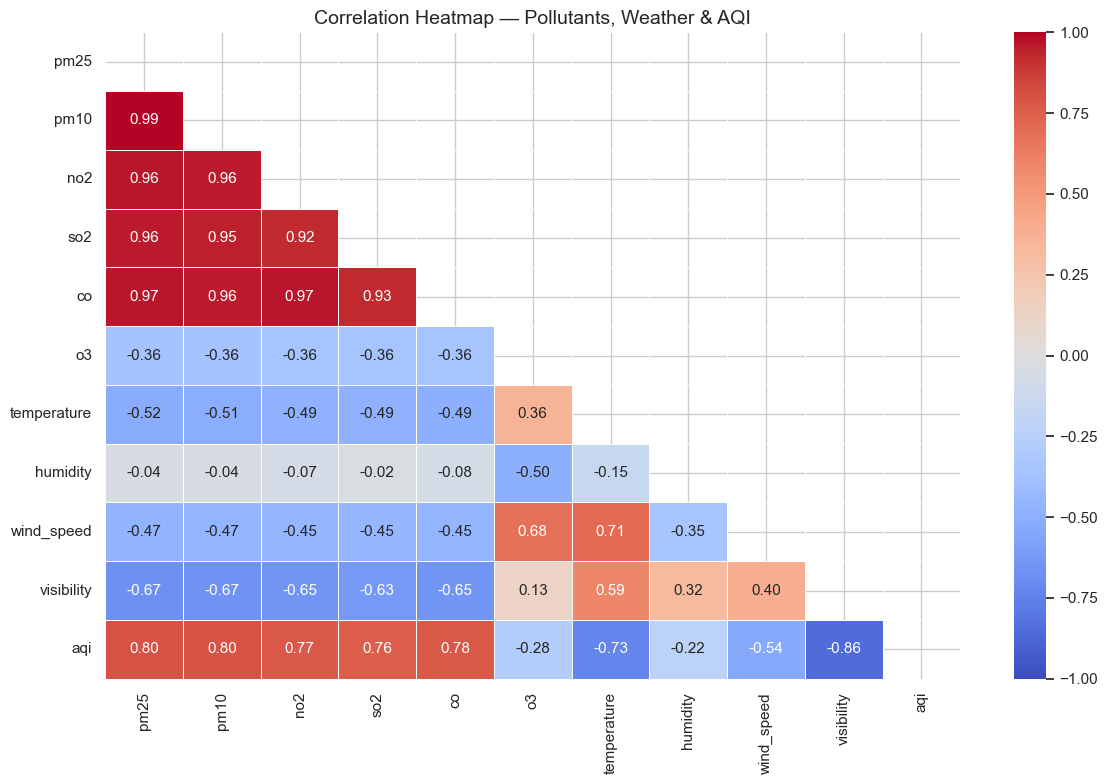

In [33]:
pollutant_cols = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3',
                  'temperature', 'humidity', 'wind_speed', 'visibility', 'aqi']

plt.figure(figsize=(12, 8))
corr_matrix = df[pollutant_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 11})

plt.title('Correlation Heatmap — Pollutants, Weather & AQI', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

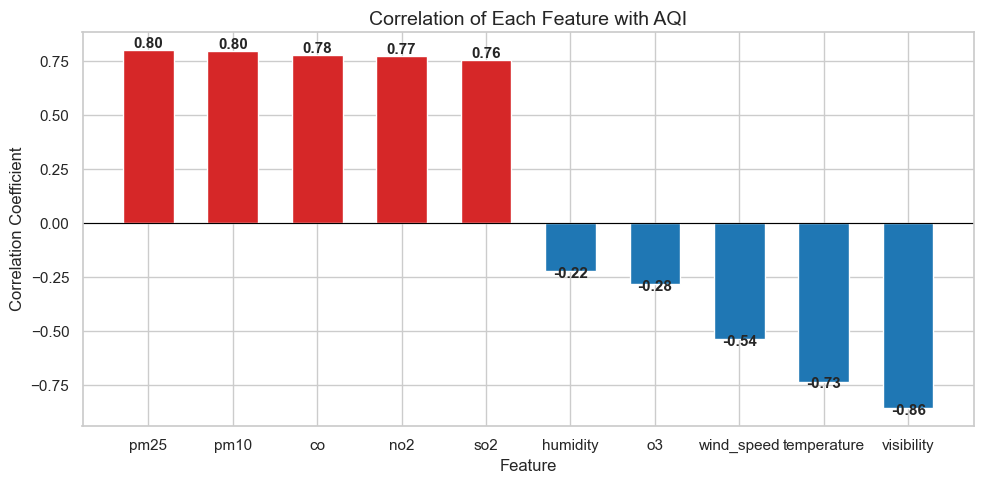

In [34]:
corr_with_aqi = df[pollutant_cols].corr()['aqi'].drop('aqi').sort_values(ascending=False)

colors = ['#d62728' if v > 0 else '#1f77b4' for v in corr_with_aqi.values]

plt.figure(figsize=(10, 5))
bars = plt.bar(corr_with_aqi.index, corr_with_aqi.values,
               color=colors, edgecolor='white', width=0.6)

for bar, val in zip(bars, corr_with_aqi.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01 if val > 0 else bar.get_height() - 0.03,
             f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.title('Correlation of Each Feature with AQI', fontsize=14)
plt.xlabel('Feature')
plt.ylabel('Correlation Coefficient')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../plots/feature_aqi_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

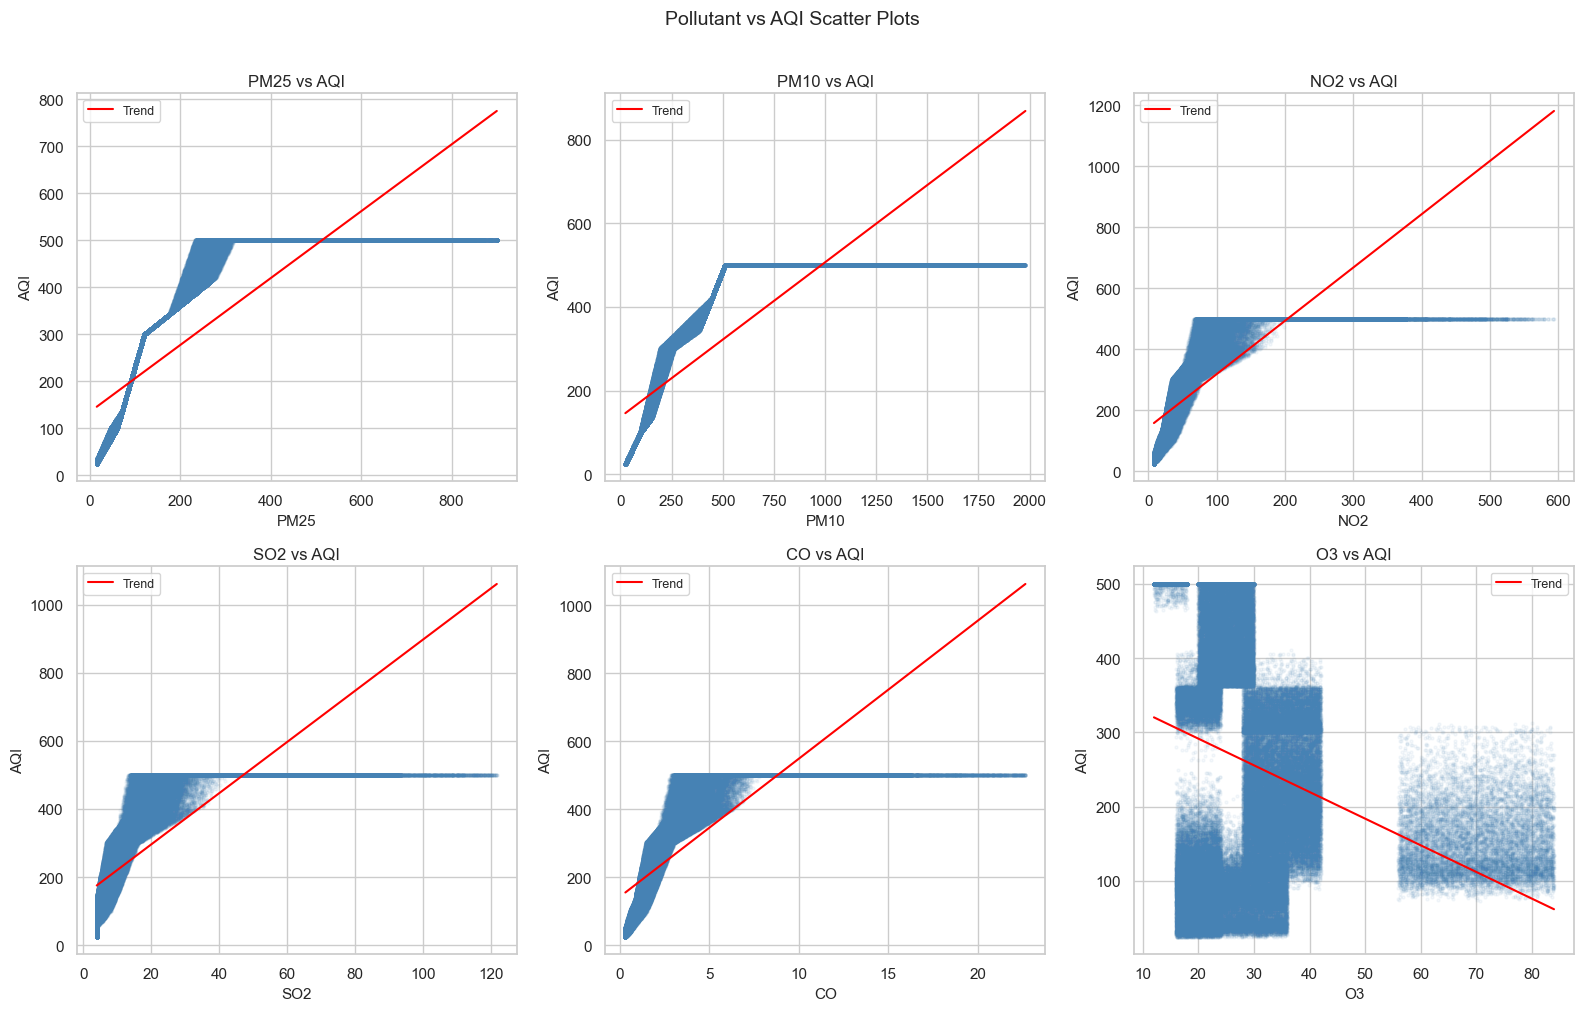

In [35]:
pollutants = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(pollutants):
    axes[i].scatter(df[col], df['aqi'], alpha=0.05,
                    color='steelblue', s=5)
    
    # Add trend line
    z = np.polyfit(df[col], df['aqi'], 1)
    p = np.poly1d(z)
    x_sorted = sorted(df[col])
    axes[i].plot(x_sorted, p(x_sorted), 
                 color='red', linewidth=1.5, label='Trend')
    
    axes[i].set_xlabel(col.upper(), fontsize=11)
    axes[i].set_ylabel('AQI', fontsize=11)
    axes[i].set_title(f'{col.upper()} vs AQI', fontsize=12)
    axes[i].legend(fontsize=9)

plt.suptitle('Pollutant vs AQI Scatter Plots', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../plots/pollutant_vs_aqi_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

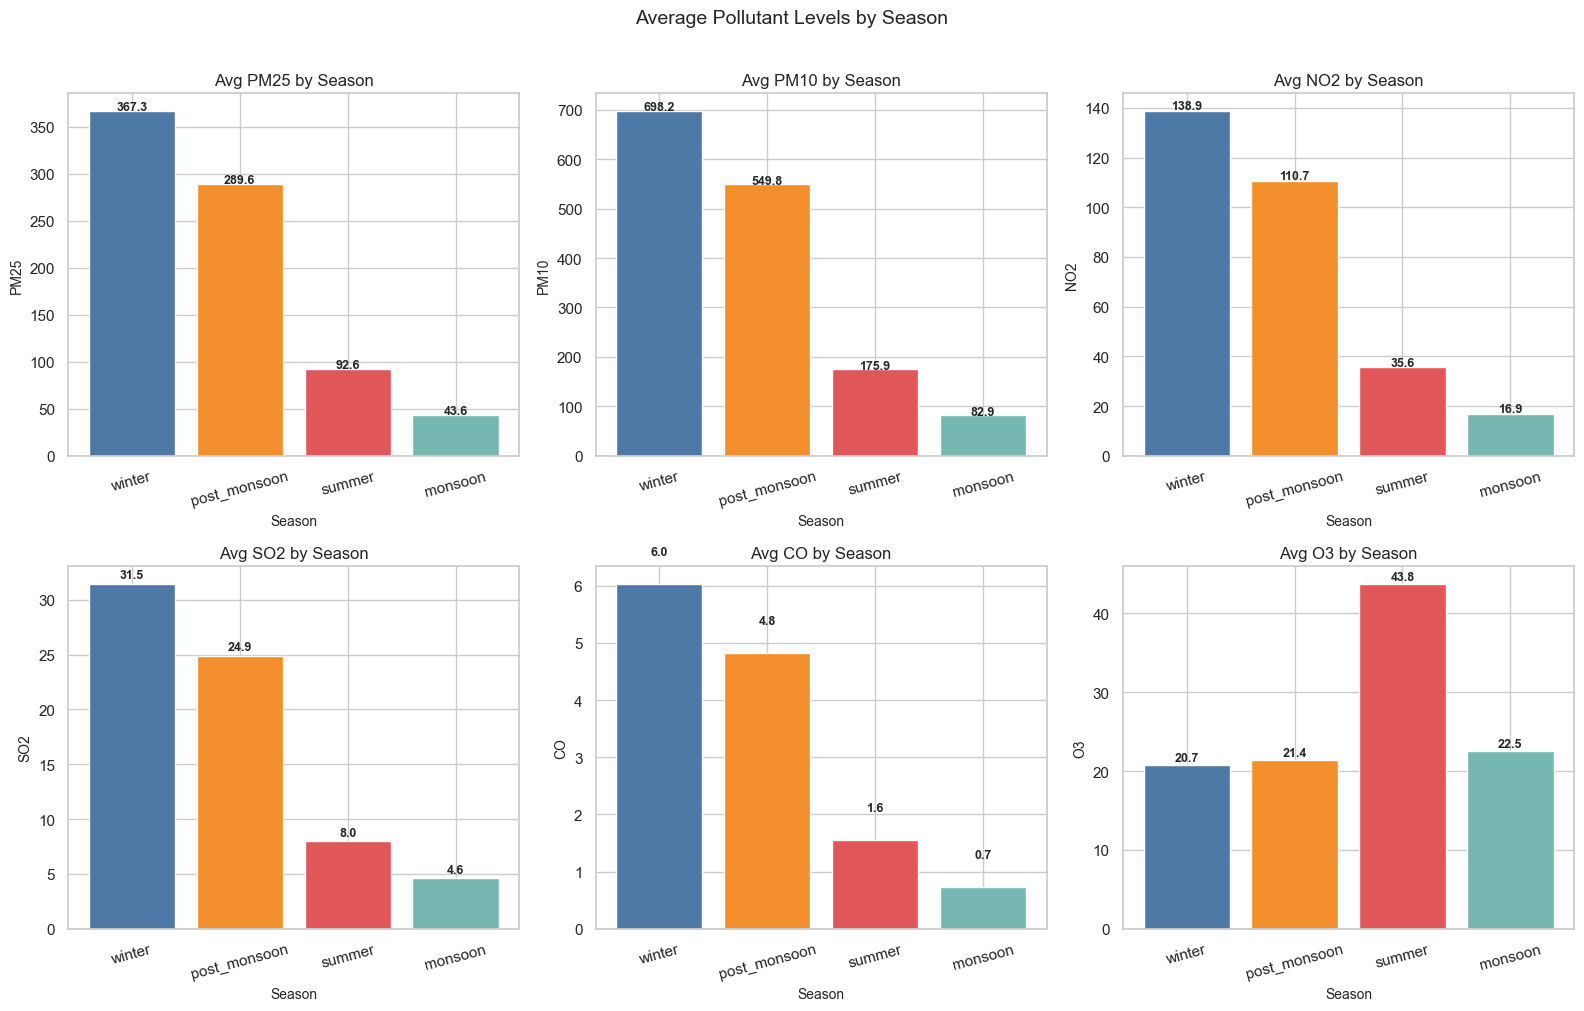

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
season_colors = ['#4e79a7','#f28e2b','#e15759','#76b7b2']

for i, col in enumerate(pollutants):
    season_poll = df.groupby('season')[col].mean().reindex(season_order)
    bars = axes[i].bar(season_poll.index, season_poll.values,
                       color=season_colors, edgecolor='white')
    
    for bar, val in zip(bars, season_poll.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')
    
    axes[i].set_title(f'Avg {col.upper()} by Season', fontsize=12)
    axes[i].set_xlabel('Season', fontsize=10)
    axes[i].set_ylabel(col.upper(), fontsize=10)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Average Pollutant Levels by Season', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../plots/pollutant_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

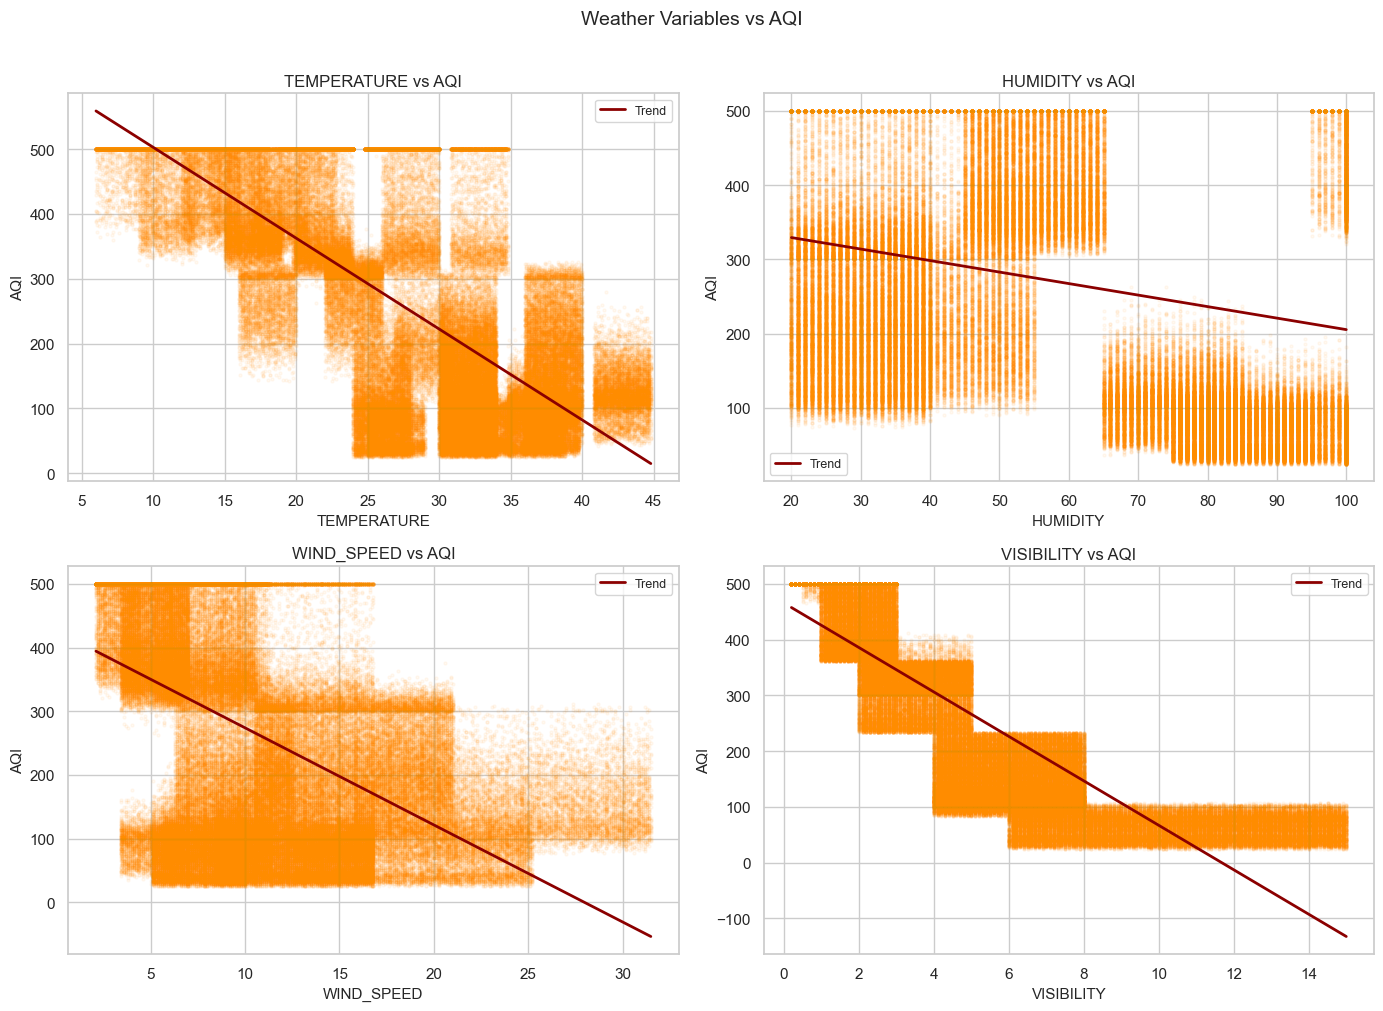

In [37]:
weather_cols = ['temperature', 'humidity', 'wind_speed', 'visibility']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(weather_cols):
    axes[i].scatter(df[col], df['aqi'], alpha=0.05,
                    color='darkorange', s=5)
    
    # Add trend line
    z = np.polyfit(df[col], df['aqi'], 1)
    p = np.poly1d(z)
    x_sorted = sorted(df[col])
    axes[i].plot(x_sorted, p(x_sorted),
                 color='darkred', linewidth=2, label='Trend')
    
    axes[i].set_xlabel(col.upper(), fontsize=11)
    axes[i].set_ylabel('AQI', fontsize=11)
    axes[i].set_title(f'{col.upper()} vs AQI', fontsize=12)
    axes[i].legend(fontsize=9)

plt.suptitle('Weather Variables vs AQI', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../plots/weather_vs_aqi.png', dpi=150, bbox_inches='tight')
plt.show()

# EDA Summary & Key Findings

## Dataset Overview
- 201,664 hourly records spanning 2020–2025
- 23 monitoring stations across 5 cities — Delhi, Noida, 
  Gurugram, Faridabad, Ghaziabad
- 25 features including pollutants, weather variables, 
  and time indicators
- Zero missing values — perfectly clean dataset

---

## 1. AQI Distribution
- Mean AQI of 265.83 places Delhi-NCR firmly in the **Poor category** on average
- Data is **right-skewed** — extreme winter values pull the mean above the median (232)
- **Severe category dominates (29.8%)** — nearly 1 in 3 hourly readings 
  is at maximum danger level
- Only 7.33% of readings fall in the Good category — 
  clean air is genuinely rare in Delhi-NCR
- AQI has shown a **marginal improvement** from 271 (2020) to 261 (2025) 
  — a drop of just 10 points over 6 years, far from adequate

---

## 2. City-wise & Station-wise Analysis
- **Ghaziabad (275)** is the most polluted city, 
  **Noida (256)** is the least polluted
- However the gap is only 19 points — **all 5 cities are 
  chronically polluted** with no city averaging below Poor category
- **Anand Vihar, Delhi (295)** is the single most polluted station — 
  located near a major bus terminal and highway interchange
- **NSIT Dwarka, Delhi (245)** is the cleanest station — 
  yet still firmly in the Poor category
- All 23 stations have equal data coverage (~8,700 records each) — 
  no bias in training data

---

## 3. Seasonal Trends
- **Season is the single most dominant factor driving AQI**
- Winter (458) and Post-monsoon (422) are catastrophic — 
  nearly 100% of readings fall in Very Poor or Severe categories
- **Monsoon (83)** is the only season where breathing is safe — 
  rainfall physically washes pollutants out of the atmosphere
- The swing from August (59) to November (500) is the 
  sharpest month-on-month rise in the entire dataset — 
  driven by crop stubble burning in Punjab and Haryana
- **6 PM in winter (481)** is the single most dangerous 
  time slot — evening traffic rush + cooling temperatures 
  trapping pollutants

---

## 4. Time-of-Day Trends
- **6 PM (282)** is the worst hour due to evening traffic rush hour
- **12 PM (243)** is the cleanest — afternoon sunlight 
  disperses pollutants through atmospheric mixing
- Hour of day has relatively minor impact (range: 243–282) 
  compared to seasonal variation (range: 83–458)

---

## 5. Pollutant Correlations
- **PM2.5 (0.80) and PM10 (0.80)** are the strongest 
  positive predictors of AQI
- **PM2.5 and PM10 are 0.99 correlated with each other** — 
  they always rise and fall together, driven by the same sources
- **CO, NO2, SO2** are all highly correlated with each other 
  (0.92–0.97) — all originate from combustion sources
- **O3 is the only pollutant negatively correlated with AQI (-0.28)** — 
  it is a photochemical pollutant that peaks in summer, 
  opposite to all other pollutants
- High inter-pollutant correlations indicate **multicollinearity** — 
  tree-based models (Random Forest, XGBoost) will handle 
  this better than Linear Regression

---

## 6. Weather Correlations
- **Visibility (-0.86)** is the strongest single predictor overall — 
  stronger than any individual pollutant
- **Temperature (-0.73)** — cold temperatures trap pollutants 
  near the ground, directly driving winter AQI spikes
- **Wind Speed (-0.54)** — higher wind disperses pollutants, 
  acting as a natural air purifier
- **Humidity (-0.22)** is the weakest predictor — 
  it has a complex and inconsistent relationship with AQI

---

## 7. Key Implications for ML Model
- The **non-linear hockey stick pattern** in pollutant vs AQI 
  scatter plots confirms tree-based models will outperform 
  Linear Regression
- **Visibility, Temperature, PM2.5, PM10, CO** will likely be 
  the top 5 most important features
- The AQI cap at 500 creates a **ceiling effect** that may 
  cause the model to underpredict extreme values — 
  to be monitored during evaluation
- **Season and month** must be included as features — 
  they capture the most variance in AQI
- High multicollinearity between pollutants won't affect 
  Random Forest or XGBoost but will hurt Linear Regression

In [40]:
print("=" * 55)
print("         EDA SUMMARY — DELHI NCR AQI DATASET")
print("=" * 55)
print(f"  Total Records       : {len(df):,}")
print(f"  Cities              : {df['city'].nunique()}")
print(f"  Stations            : {df['station'].nunique()}")
print(f"  Date Range          : 2020 – 2025")
print(f"  Missing Values      : 0")
print("-" * 55)
print(f"  Mean AQI            : {df['aqi'].mean():.1f} (Poor)")
print(f"  Worst Month         : November (Avg AQI = 500)")
print(f"  Best Month          : August  (Avg AQI = 59)")
print(f"  Most Polluted City  : Ghaziabad (Avg AQI = 275)")
print(f"  Cleanest City       : Noida     (Avg AQI = 256)")
print(f"  Worst Station       : Anand Vihar, Delhi (295)")
print(f"  Cleanest Station    : NSIT Dwarka, Delhi (245)")
print(f"  Worst Season        : Winter (Avg AQI = 458)")
print(f"  Best Season         : Monsoon (Avg AQI = 83)")
print(f"  Worst Hour          : 6 PM   (Avg AQI = 282)")
print(f"  Best Hour           : 12 PM  (Avg AQI = 243)")
print("-" * 55)
print(f"  Top Positive Feature: PM2.5 & PM10  (r = 0.80)")
print(f"  Top Negative Feature: Visibility     (r = -0.86)")
print(f"  Weakest Feature     : Humidity       (r = -0.22)")
print("=" * 55)

         EDA SUMMARY — DELHI NCR AQI DATASET
  Total Records       : 201,664
  Cities              : 5
  Stations            : 23
  Date Range          : 2020 – 2025
  Missing Values      : 0
-------------------------------------------------------
  Mean AQI            : 265.8 (Poor)
  Worst Month         : November (Avg AQI = 500)
  Best Month          : August  (Avg AQI = 59)
  Most Polluted City  : Ghaziabad (Avg AQI = 275)
  Cleanest City       : Noida     (Avg AQI = 256)
  Worst Station       : Anand Vihar, Delhi (295)
  Cleanest Station    : NSIT Dwarka, Delhi (245)
  Worst Season        : Winter (Avg AQI = 458)
  Best Season         : Monsoon (Avg AQI = 83)
  Worst Hour          : 6 PM   (Avg AQI = 282)
  Best Hour           : 12 PM  (Avg AQI = 243)
-------------------------------------------------------
  Top Positive Feature: PM2.5 & PM10  (r = 0.80)
  Top Negative Feature: Visibility     (r = -0.86)
  Weakest Feature     : Humidity       (r = -0.22)
